# F1 Grand Prix Predictor
### Final Project Notebook Simple Draft

This notebook serves as an early outline for the final group submission.  
Each section below matches a required project deliverable and I'll try to fill it/track what's being done with it

## 1. Problem and Dataset Overview

**Project type:** (I think its Regression..?)

**Goal:** Use Formula 1 race, driver, weather, and track information to predict an F1 driver's time.

**Target variable:** Lap Duration

**Dataset:** OpenF1 data, with at least 15,000 samples planned for the project.

**Main features may include:**
- Driver number
- Team name
- Air temperature
- Track temperature
- Humidity
- Rainfall
- Session type
- Track curvature
- Starting grid position

**To add later:**
- Final dataset size
- Final list of features
- Short explanation of why the prediction problem is useful (I've got ideas, wanna ask about that in the meeting)
- A small preview of the dataset (I can do this if needed)

## 2. Exploratory Data Analysis and Visualizations

This section should help the reader understand the dataset before modeling.

**Include:**
- Dataset dimensions and column types
- Missing-value summary
- Distribution of the target variable
- Summary statistics for numerical features
- Counts for important categorical features
- Relationships between useful features and lap duration
- Track or curvature visualization, if available

**Possible visuals:**
- Histogram of lap duration
- Correlation heatmap
- Box plots by driver, team, or session type
- Weather versus lap duration scatter plots
- Track path or curvature plot

Each visualization should have a short explanation of what it shows and why it matters.

,session_key,driver_number,date_start,lap_duration,air_temperature,track_temperature,humidity,rainfall,meeting_key,circuit_key,circuit_short_name,session_name,session_type,circuit_curvature,team_name,position,has_grid_position
0,7765,2,2023-03-03T11:30:07.574Z,NaN,27.400000,41.900000,11.0,0.0,1141,63,Sakhir,Practice 1,Practice,28.276951,Williams,0,False
1,7765,77,2023-03-03T11:30:09.215Z,129.966,27.400000,41.850000,11.0,0.0,1141,63,Sakhir,Practice 1,Practice,28.276951,Alfa Romeo,0,False
2,7765,24,2023-03-03T11:30:14.011Z,140.357,27.400000,41.850000,11.0,0.0,1141,63,Sakhir,Practice 1,Practice,28.276951,Alfa Romeo,0,False
3,7765,4,2023-03-03T11:30:16.168Z,128.935,27.400000,41.850000,11.0,0.0,1141,63,Sakhir,Practice 1,Practice,28.276951,McLaren,0,False
4,7765,81,2023-03-03T11:30:26.277Z,142.794,27.366667,41.833333,11.0,0.0,1141,63,Sakhir,Practice 1,Practice,28.276951,McLaren,0,False


<class 'pandas.DataFrame'>
RangeIndex: 228212 entries, 0 to 228211
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   session_key         228212 non-null  int64  
 1   driver_number       228212 non-null  int64  
 2   date_start          228212 non-null  str    
 3   lap_duration        219719 non-null  float64
 4   air_temperature     228212 non-null  float64
 5   track_temperature   228212 non-null  float64
 6   humidity            228212 non-null  float64
 7   rainfall            228212 non-null  float64
 8   meeting_key         228212 non-null  int64  
 9   circuit_key         228212 non-null  int64  
 10  circuit_short_name  228212 non-null  str    
 11  session_name        228212 non-null  str    
 12  session_type        228212 non-null  str    
 13  circuit_curvature   228212 non-null  float64
 14  team_name           228212 non-null  str    
 15  position            228212 non-null  int64  


None

,session_key,driver_number,lap_duration,air_temperature,track_temperature,humidity,rainfall,meeting_key,circuit_key,circuit_curvature,position
count,228212.00000,228212.000000,219719.000000,228212.000000,228212.000000,228212.000000,228212.000000,228212.000000,228212.000000,228212.000000,228212.000000
mean,9762.40178,29.537356,130.897726,23.907083,36.158116,51.466635,0.032433,1245.451918,51.478494,461.763991,4.894116
std,754.32316,24.302899,152.338399,5.020175,9.029598,16.467927,0.172564,30.658504,51.094789,1551.194363,6.545463
min,7765.00000,1.000000,60.351000,10.800000,0.000000,11.000000,0.000000,1141.000000,2.000000,20.635786,0.000000
25%,9278.00000,11.000000,82.778500,20.400000,30.650000,38.500000,0.000000,1226.000000,14.000000,30.518520,0.000000
50%,9621.00000,22.000000,94.677000,24.200000,36.560000,53.000000,0.000000,1247.000000,23.000000,33.049545,0.000000
75%,9963.00000,44.000000,111.354000,27.650000,42.900000,63.000000,0.000000,1268.000000,65.000000,37.447357,10.000000
max,11342.00000,98.000000,3225.697000,35.750000,60.600000,96.000000,1.000000,1291.000000,152.000000,6953.170405,22.000000


(228212, 17)

driver_number count: 51
circuit_key count: 24
session_name count: 7
team_name count: 15


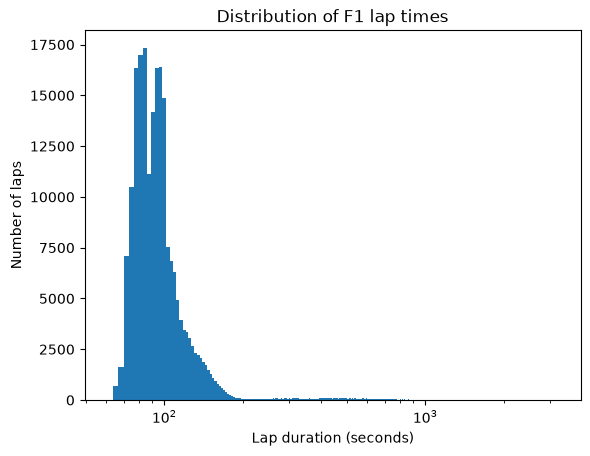

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json("Master.json")


display(df.head())
display(df.info())
display(df.describe())
display(df.shape)

categorical_features = ["driver_number", "circuit_key", "session_name", "team_name"]
numerical_features = ["air_temperature", "track_temperature", "humidity", "rainfall", "position", "has_grid_position"]
for feature in categorical_features:
    print(f"{feature} count: {len(list(set(df[feature])))}")

plt.hist(df["lap_duration"], bins=1000)
plt.xscale("log")
plt.xlabel("Lap duration (seconds)")
plt.ylabel("Number of laps")
plt.title("Distribution of F1 lap times")
plt.show()

# Observe this graph is wildly left-skewed. This will be addressed.

# Needs correlation matrix

# We will get more features such as tire type and age and maybe if the lap is a pit lap.

## 3. Data Cleaning and Preprocessing

(Do we have a single person doing Data Cleaning/Preprocessing or a more independent/by case approach?)

This section should explain how the raw data is prepared for the models.

**Main steps:**
- Remove duplicate or unusable rows
- Handle missing values
- Separate the input features from the target
- Split the data into training and testing sets
- One-hot encode categorical features
- Scale numerical features when appropriate
- Keep preprocessing consistent across all models

(if we are doing different things in different sections of the code, I could just reference back bits and pieces and how they pertain to certain models or not etc..)

**To add later:**
- Final preprocessing pipeline
- Number of rows removed or changed
- Final training and testing set sizes
- Explanation of any important cleaning decisions

In [8]:
df = df.dropna().drop_duplicates()

# Within lap times, the maximum values are drastically large, and it can be reasonably assumed they are erronious.
# Thus I will remove the 93rd percentile of laps so the linear regression models won't be penalized by unrealistic lap times.
cutoff = df["lap_duration"].quantile(0.93)
df_cleaned = df[df["lap_duration"] <= cutoff]

display(df_cleaned[["lap_duration"]].describe())
display(df_cleaned.info())

,lap_duration
count,202103.00000
mean,97.57565
std,21.36394
min,60.35100
25%,82.09300
50%,93.25800
75%,106.06450
max,191.08400


<class 'pandas.DataFrame'>
Index: 202103 entries, 1 to 228211
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   session_key         202103 non-null  int64  
 1   driver_number       202103 non-null  int64  
 2   date_start          202103 non-null  str    
 3   lap_duration        202103 non-null  float64
 4   air_temperature     202103 non-null  float64
 5   track_temperature   202103 non-null  float64
 6   humidity            202103 non-null  float64
 7   rainfall            202103 non-null  float64
 8   meeting_key         202103 non-null  int64  
 9   circuit_key         202103 non-null  int64  
 10  circuit_short_name  202103 non-null  str    
 11  session_name        202103 non-null  str    
 12  session_type        202103 non-null  str    
 13  circuit_curvature   202103 non-null  float64
 14  team_name           202103 non-null  str    
 15  position            202103 non-null  int64  
 16  

None

## 4. Model Implementation

The project must compare at least three appropriate machine learning algorithms.

### Model 1: Linear Regression
Use as a simple baseline model.

### Model 2: Random Forest Regressor
Use to capture nonlinear relationships and feature interactions.

### Model 3: Neural Network Regressor
Use as a more flexible model for complex patterns.

For every model, the notebook should show:
- Model setup
- Training process
- Predictions on the test set
- Evaluation results

All models should use the same target, data split, and evaluation metrics.

## 5. Model Tuning and Evaluation

The models should be tuned and evaluated consistently.

**Planned evaluation metrics:**
- RMSE
- MAE
- R²

**Planned tuning approach:**
- Cross-validation
- Grid search for suitable models
- Neural-network tuning as appropriate

### Results Table

| Model | Best Settings | RMSE | MAE | R² |
|---|---|---:|---:|---:|
| Linear Regression | TBD | TBD | TBD | TBD |
| Random Forest | TBD | TBD | TBD | TBD |
| Neural Network | TBD | TBD | TBD | TBD |

The same test set should be used for the final comparison.

## 6. Model Comparison and Results Interpretation

This section should explain what the final numbers actually mean.

**Questions to answer:**
- Which model performed best?
- Which evaluation metrics support that choice?
- How large was the difference between the models?
- Did any model appear to overfit?
- What types of predictions were most or least accurate?
- Which features appear to influence the predictions?
- What do the results mean in the context of Formula 1?

The best-performing model should be clearly identified and justified instead of only listing its score.

## 7. Final Conclusions and Limitations

**Final conclusion should summarize:**
- The prediction problem
- The models tested
- The best-performing model
- The main result
- Whether the project goal was achieved

**Possible limitations to discuss:**
- Missing or incomplete race data
- Limited seasons or sessions
- Unusual race conditions
- Engineered track-curvature accuracy
- Features that were not available
- Difficulty generalizing to future races

## 8. Team Contributions

| Group Member | Main Contribution |
|---|---|
| Sean Staszewski | Dataset collection, documentation, feature engineering, and model implementation |
| Meechai Kerr | Exploratory data analysis, visualization, cleaning, and preprocessing |
| Miguel Gutierrez | Model implementation, evaluation, and comparison |
| Gabriel Lopez-Garcia | Cross-validation, tuning, preprocessing pipeline, and data cleaning |
| Andres Chavez | Results interpretation, presentation preparation, and delivery |

Not too sure how accurate this is, this section should be updated as we go.

## 9. Final Submission Checklist

Before submitting, confirm that the notebook includes:

- [ ] Problem and dataset overview
- [ ] Clearly defined target variable
- [ ] Exploratory data analysis and visualizations
- [ ] Data cleaning and preprocessing
- [ ] At least three machine learning algorithms
- [ ] Model tuning and evaluation
- [ ] Consistent RMSE, MAE, and R² results
- [ ] Model comparison and results interpretation
- [ ] Identification and justification of the best model
- [ ] Final conclusions and limitations
- [ ] Summary of every member's contribution
- [ ] Clear Markdown explanations
- [ ] Readable code
- [ ] Outputs that run successfully

**Final step:** Restart the notebook environment and run every cell from beginning to end before submission.